# Imports and Libraries

## Installs

Dataset and code for downloading found:
[1] Stanford NLP, “stanfordnlp/sst2,” Hugging Face. [Online]. Available: https://huggingface.co/datasets/stanfordnlp/sst2. [Accessed: Aug. 19, 2026].

In [ ]:
# Setup command
#%pip install -U torch transformers datasets accelerate scikit-learn pandas matplotlib

## Imports

`load_dataset` - For downloading sst2 dataset

`DatasetDict` - For creating project dataset splits

`pd` - For usage of DataFrame type

`AutoTokenizer` - For tokenisation of datasets required for transformer based models

`np` - Used in evaluation metrics for finding highest model output score

`accuracy_score` - Used to calculate overall accuracy of model

`precision_recall_fscore_support` - Used to calculate precision, recall, F1 and support of model

`AutoModelForSequenceClassification` - Used to load tansformer model for classification tasks

`DataCollatorWithPadding` - Used for padding training batches

`TrainingArguments` - Sets training arguments for model during training

`Trainer` - Joins together model arguments, model, datasets, collator, metrics, etc. to train model

`plt` - Used to plot model results

`random` - Used when creating noise 

In [66]:
from datasets import load_dataset, DatasetDict
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import random

# Dataset

`dataframe_check` function:

- Takes:
  - `dataframe`: DataFrame containing training, validation and testing data


This function performs a couple of manual checks on the dataset for inspection by the user. For example, printing the first few values and checking the balance.

In [67]:
def dataframe_check(dataframe):
    # Check first couple values
    print("Dataframe head:")
    print(dataframe.head())
    print("\n-----------------------------------")
    print("\nBalance of dataset")
    print(dataframe["label"].value_counts())
    print(dataframe["label"].value_counts(normalize=True))

Load the sst2 dataset.

In [68]:
sst2 = load_dataset("glue", "sst2")

Convert to a dataframe and call the `dataframe_check` function to print some infomation about the training data

In [69]:
train_df = pd.DataFrame(sst2["train"])
dataframe_check(train_df)

Dataframe head:
                                            sentence  label  idx
0       hide new secretions from the parental units       0    0
1               contains no wit , only labored gags       0    1
2  that loves its characters and communicates som...      1    2
3  remains utterly satisfied to remain the same t...      0    3
4  on the worst revenge-of-the-nerds clichés the ...      0    4

-----------------------------------

Balance of dataset
label
1    37569
0    29780
Name: count, dtype: int64
label
1    0.557826
0    0.442174
Name: proportion, dtype: float64


# Create dataset splits

The SST-2 has hidden labels for test data so only training and validation data will be taken into account. Training data will be split into training and testing.

In [70]:
train_test_split = sst2["train"].train_test_split(
    test_size = 0.2, # 20% used for testing
    seed = 42, # Seed for database split
    stratify_by_column = "label" # Keep label balance after split
)

# Remake DatasetDict with new split, since original had no test data labels
sst2_split = DatasetDict({
    "train": train_test_split["train"],
    "validation": sst2["validation"],
    "test": train_test_split["test"]
})

# Tokenisation of data

`tokenise_dataset` function:

- Takes:
  - `tokenizer`: AutoTokenizer used to convert text into token IDs
  - `raw_dataset`: Dataset of raw values such as plain text sentences and labels
  - `max_length`: Integer that limits each sentence to max_length tokens

- Returns:
  - `tokenized_dataset`: Dataset that has now been tokenized ready for model training/evaluation


This function takes a dataset with raw values and tokenizes them using the provided tokenizer ready for transformer based model training and evaluation.

`tokenize` function:

- Takes:
  - `batch`: Dictionary batch of rows from dataset

- Returns:
  - `tokenizer`: BatchEncoding dictionary containing numerical token IDs


This function takes a batch of dataset rows and converts the sentences into token IDs. Also removed sentences longer than 128 tokens.

In [71]:
def tokenize_dataset(tokenizer, raw_dataset, max_length=128): 
    def tokenize(batch):
        return tokenizer(
            batch["sentence"], # select sentence text from dataset
            truncation=True, # cuts off text if it is too long
            padding="max_length",
            max_length=max_length # limits each sentence to max_length tokens. enough for SST2 due to short sentences
        )

    
    # Applies tokenize function to each sentence
    tokenized_dataset = raw_dataset.map(tokenize, batched=True)

    # Remove columns no longer needed for training such as sentences, index. If they are even present
    columns_to_remove = [
        column for column in ["sentence", "idx", "token_type_ids"]
        if column in tokenized_dataset.column_names]
    tokenized_dataset = tokenized_dataset.remove_columns(columns_to_remove)

    # Rename column label to labels for compatibility if not already
    if "label" in tokenized_dataset.column_names:
        tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

    # Return Pytorch tensor for tokenized_sst2
    tokenized_dataset.set_format("torch")

    
    return tokenized_dataset

# Setup Evaluation Metrics

`evaluation_metrics` function:

- Takes:
  - `eval_prediction`: Tuple containing raw model predictions and correct labels

- Returns:
  - `Dictionary`: Dictionary of evaluation results including precision, recall, f1 and accuracy


This function takes models predictions and correct labels and returns a series of evaluation metrics about those predictions including accuracy, recall, f1 and precision.

In [72]:
def compute_metrics(eval_prediction):
    # Split incoming prediction into model prediction and correct labels
    raw_data, labels = eval_prediction

    # Convert output to class prediciton
    predictions = np.argmax(raw_data, axis=-1)

    # Compare predictions against labels
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, 
        predictions,
        average="binary" # binary as sst2 has binary labels 1 or 0.
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

# Defining Training Arguments

[2] Hugging Face, “Trainer,” Hugging Face Transformers documentation, version 4.15.0. [Online]. Available: https://huggingface.co/docs/transformers/v4.15.0/en/main_classes/trainer#transformers.TrainingArguments. [Accessed: Aug. 19, 2026].

`train_model` function:

- Takes:
  - `model_name`: String contianing model name
  - `tokenizer`: AutoTokenizer used for selected model
  - `tokenized_train_dataset`: Dataset containing tokenised training data
  - `tokenized_validation_dataset`: Dataset containing tokenised validation data
  - `output_dir`: String folder path where training outputs saved
  - `compute_metrics`: Function used to calculate evaluation metrics during training
  - `leanring_rate`: Float controlling how quickly the model updates during training
  - `per_device_train_batch_size`: Integer setting training batch size
  - `per_device_eval_batch_size`: Integer setting evaluation batch size
  - `num_train_epochs`: Integer setting how many times model trains through dataset
  - `weight_decay`: Float used to reduce overfitting during training

- Returns:
  - `trainer`: Trainer object containing the trained model and setup


This function takes a transformer model and trains it using the tokenised training dataset. It sets the training arguments and then creates a trainer for the model. Finally, it runs the training process and returns the trained Trainer object so it can be used later for evaluation on clean and noisy test data.

In [73]:
def train_model(
    model_name,
    tokenizer,
    tokenized_train_dataset,
    tokenized_validation_dataset,
    output_dir,
    compute_metrics,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01
):

    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2 # Number of outputs (1, 0)
    )

    
    training_args = TrainingArguments(
        output_dir=output_dir, # Output for trianing files
        eval_strategy="epoch", # Evaluation after each epoch
        save_strategy="epoch", # Save Model after each epoch
        learning_rate=learning_rate, 
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_eval_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True, # Keeps best saved model
        metric_for_best_model="f1", # How it decides which model is best
        greater_is_better=True, # Dictates higher F1 is better
        report_to="none" # Stop hugging face logging data
    )


    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_validation_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )


    trainer.train()

    return trainer

# Training Graphs

`training_graphs` function:

- Takes:
  - `history`: Dataframe containing the training log history from the Trainer
  - `model_name`: String containing the name of the model being plotted


This function creates graphs to show how the model performed during training.

In [74]:
def training_graphs(history, model_name):
    train_loss = history.dropna(subset=["loss"]) # DataFrame with only loss
    eval_loss = history.dropna(subset=["eval_loss"]) # DataFrame with only eval_loss
    
    # Plot the 2 DataFrames
    plt.plot(train_loss["epoch"], train_loss["loss"], marker="o", label="Training loss")
    plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], marker="o", label="Validation loss")
    
    # Label the Axis and provide Title
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(model_name + " Training vs Validation Loss")
    
    # Add Legend and show graph
    plt.legend()
    plt.grid(True)
    plt.show()
    
    eval_metrics = history.dropna(subset=["eval_f1"]) # Dataframe of just eval_f1 rows
    
    # Plot the DataFrame
    plt.plot(eval_metrics["epoch"], eval_metrics["eval_f1"], marker="o", label="Validation F1")
    
    # Label the Axis and provide Title
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title(model_name + " Validation F1 Over Epochs")
    
    # Add Legend and show graph
    plt.legend()
    plt.grid(True)
    plt.show()

# Model Evaluation

`model_evaluation` function:

- Takes:
  - `tokenized_test_data`: Dataset containing tokenised test data ready for model evaluation
  - `trainer`: Trainer containing the trained model
  - `data_name`: String name of type of data that was provided to function

- Returns:
  - `results`: Dataframe of evaluation results including precision, recall, f1 and accuracy


This function evaluates a trained model on a tokenised test dataset. Uses the Trainer to run the model on the provided test data and collect the evaluation results.

In [75]:
def model_evaluation(tokenized_test_data, trainer, data_name):
    test_results = trainer.evaluate(tokenized_test_data)

    results = pd.DataFrame([
        {
            "Data": data_name,
            "Loss": test_results["eval_loss"],
            "Accuracy": test_results["eval_accuracy"],
            "Precision": test_results["eval_precision"],
            "Recall": test_results["eval_recall"],
            "F1": test_results["eval_f1"]
        }
    ])

    results = results.round(3)

    print(results.to_string(index=False))

    return results

# Noisy Dataset Helper Functions

## Creating Noisy Dataset Helper Function

`create_noisy_dataset` function:

- Takes:
  - `dataset`: Dataset of sentences and labels to have noise applied to
  - `noise_function`: Function representing some type of noise application function
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10% 

- Returns:
  - `noisy_dataset`: Dataset of sentneces and labels that have had a specific level of noise applied


This function takes a dataset, a noise application function e.g. OCR and the level of noise e.g. 10% and returns the dataset with unchanged labels but with now noisy sentences.

`apply_noise` function:

- Takes:
  - `dataset_row`: Dictionary dataset row to have noise applied to

- Returns:
  - `noisy_sentence`: Disctionary of the new sentence with noise added 


This function takes a row from a dataset and applies a provided noise function to that sentence and then returns it.

In [76]:
def create_noisy_dataset(dataset, noise_function, noise_level):

    
    # Function to apply noise depending on noise_function given
    def apply_noise(dataset_row):
        noisy_sentence = noise_function(dataset_row["sentence"], noise_level)

        return {"sentence": noisy_sentence} # Reokaces original with noisy in dataset row


    noisy_dataset = dataset.map(apply_noise) # Apply apply_noise to every row in dataset

    return noisy_dataset

## Testing Sentences with noise Helper Function

`test_noise_function` function:

- Takes:
  - `sample_sentence`: String of sentence to go through adding noise process
  - `noise_function`: Function for which the sentence should be passed to, to create the noise


This function takes an example sentence and a desired noise function and runs a test on that sentence at different noise levels and prints the results.

In [77]:
def test_noise_function(sample_sentence, noise_function):   
    print("Original:")
    print(sample_sentence)
    
    print("\nNoisy Level 0.1:")
    print(noise_function(sample_sentence, noise_level=0.1))
    
    print("\nNoisy Level 0.3:")
    print(noise_function(sample_sentence, noise_level=0.3))
    
    print("\nNoisy Level 0.5:")
    print(noise_function(sample_sentence, noise_level=0.5))

## Tokenize and Evaluate Function

`tokenize_and_evaluate` function:

- Takes:
  - `tokenizer`: AutoTokenizer used to convert raw text into token IDs
  - `trainer`: Trainer containing the trained model
  - `raw_test_data`: Dataset containing raw sentences and labels 
  - `data_name`: String name of type of data that was provided to function

- Returns:
  - `results`: Dataframe of evaluation results including precision, recall, f1 and accuracy

This function takes raw test dataset and applies tokenization to it and then calls the model evaluation function which evaluates and prints the results.

In [78]:
def tokenize_and_evaluate(tokenizer, trainer, raw_test_data, data_name):
    tokenized_test_data = tokenize_dataset(tokenizer, raw_test_data)
    results = model_evaluation(tokenized_test_data, trainer, data_name)
    
    return results

## Displaying graph Helper Function

`accuracy_f1_graph` function:

- Takes:
  - `results_df`: Dataframe of the results for Loss, Accuracy, Precision, Recall and F1
  - `noise_type`: String of the type of noise that was applied
  - `model_name`: String for the name of the model that was used to get the results


This function takes the results from a evaluation and prints a graph that shows those results plotted along with a title and labelled axises.

In [104]:
def accuracy_f1_graph(results_df, noise_type, model_name):
    plt.figure(figsize=(10, 5))
    
    # Plot the DataFrame for Accuracy
    plt.plot(results_df["Data"], results_df["Accuracy"], marker="o", label="Accuracy")
    
    # Plot the DataFrame for F1
    plt.plot(results_df["Data"], results_df["F1"], marker="o", label="F1 Score")
    
    # Label the Axis and provide Title
    plt.xlabel(noise_type + " Noise Level")
    plt.ylabel("Score")
    plt.title(model_name + " Performance With "+ noise_type + " Noise")

    # Keep y-axis fixed for fair comparison
    plt.ylim(0, 1)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    # Add Legend and show graph
    plt.legend()
    plt.grid(True)
    plt.show()

## Creating Tokenize Evaluate different Noise Levels Helper Function

`create_tokenize_evaluate_noise_levels` function:

- Takes:
  - `tokenizer`: AutoTokenizer used to convert noisy text into token IDs
  - `trainer`: Trainer containing the trained model
  - `noise_levels`: List of floats representing different noise levels
  - `noise_function`: Function used to apply a selected noise to test data
  - `noise_name`: String name of the noise type being evaluated

- Returns:
  - `noise_results_df`: DataFrame containing evaluation results for all tested noise levels


This function evaluates a trained model on several noisy versions of the test dataset. For each noise level, it creates a noisy version of the data using the noise function. The noisy dataset is then tokenised using the model tokenizer and evaluated using the trained model. Each set of results is stored in a list, and all results are combined into a DataFrame at the end.

In [80]:
def create_tokenize_evaluate_noise_levels(tokenizer, trainer, noise_levels, noise_function, noise_name):
    # Generating evaluation results for different noise levels
    noise_levels
    
    noise_results = []
    
    for noise_level in noise_levels:
        noisy_test_dataset = create_noisy_dataset(sst2_split["test"], noise_function, noise_level)
        tokenized_noisy_test_data = tokenize_dataset(tokenizer, noisy_test_dataset)
        results = model_evaluation(tokenized_noisy_test_data, trainer, noise_name + " " + str(noise_level))
        
        noise_results.append(results)
    
    
    # Add all dataframe results into one
    noise_results_df = pd.concat(noise_results, ignore_index = True)
    
    print(noise_results_df.to_string())
    
    return noise_results_df

## Adding result Dataframes Together Helper Function

`add_2_dataframe_results` function:

- Takes:
  - `first_results_df`: DataFrame containing first set of evaluation results
  - `second_results_df`: DataFrame containing second set of evaluation results

- Returns:
  - `combined_results_df`: DataFrame containing both sets of evaluation results combined together


This function combines two results DataFrames into one larger DataFrame.

In [81]:
def add_2_dataframe_results(first_results_df, second_results_df):
    combined_results_df = pd.concat(
        [
            first_results_df,
            second_results_df
        ],
        ignore_index = True
    )

    return combined_results_df

## Running Noise for all Models Helper Function

`all_models_for_noise` function:

- Takes:
  - `tokenizers`: List containing tokenizers for each model
  - `trainers`: List containing trained Trainers for each model
  - `model_results`: List containing clean test result DataFrames for each model
  - `models`: List containing model names
  - `noise_function`: Function used to apply selected noise type to test data
  - `noise_name`: String name of noise type being evaluated
  - `noise_levels`: List of float values representing the different noise levels to test

- Returns:
  - `all_results_df`: DataFrame containing clean and noisy evaluation results for all models


This function evaluates all trained models against one selected type of noise. For each model, it creates and evaluates noisy test datasets at each noise level. The function also adds the model name and noise type as columns at the start of the DataFrame. It then creates an accuracy and F1 graph for each model and stores the results. Finally, all model results are combined into one DataFrame and returned.

In [82]:
def all_models_for_noise(tokenizers, trainers, model_results, models, noise_function, noise_name, noise_levels):
    all_results = []

    
    for tokenizer, trainer, model_result, model in zip(tokenizers, trainers, model_results, models):
        noise_results_model_df = create_tokenize_evaluate_noise_levels(tokenizer, trainer, noise_levels, noise_function, noise_name)
        noise_results_with_clean_model_df = add_2_dataframe_results(model_result, noise_results_model_df)

        noise_results_with_clean_model_df.insert(0, "Model", model)
        noise_results_with_clean_model_df.insert(1, "Noise Type", noise_name)
        
        accuracy_f1_graph(noise_results_with_clean_model_df, noise_name, model)

        all_results.append(noise_results_with_clean_model_df)

    return pd.concat(all_results, ignore_index = True)

# OCR Noise Function

[3] J. Kiley, “Exploration inspiration: Common OCR letter misinterpretations,” Community History Archives Insights. [Online]. Available: https://communityhistoryarchives.com/100-common-ocr-letter-misinterpretations/. [Accessed: Aug. 19, 2026].

In [83]:
ocr_confusions = {
    "a": ["o", "e"],
    "b": ["o", "h"],
    "c": ["e", "o", "0"],
    "d": ["cl", "a", "o", "3", "8"],
    "e": ["c", "a", "o", "3", "8"],
    "f": ["i", "t", "l", "1", "|"],
    "g": ["q", "B", "8", "9", "y"],
    "h": ["n", "m", "b", "ln"],
    "i": ["l", "1", "|"],
    "j": ["i", "t", "1"],
    "k": ["h", "x", "b", "|<"],
    "l": ["1", "j", "I", "|"],
    "m": ["rn", "nn", "rr", "^^", "w", "iii"],
    "n": ["r", "ri", "h", "11"],
    "o": ["0", "c", "e", "*", "$", "@"],
    "p": ["f", "b", "o", "a", "9"],
    "q": ["g", "o", "a", "cl", "@"],
    "r": ["n", "v", "i"],
    "s": ["5", "z", "$", "8"],
    "t": ["f", "+", "l"],
    "u": ["y", "n", "v"],
    "v": ["u", "y", "\\/"],
    "w": ["vv", "m", "uu"],
    "x": ["k", "+", "><"],
    "y": ["v", "g", "j", "u", "7"],
    "z": ["2", "s", ">"]
}

## Creating OCR Noisy Sentences

`add_ocr_noise` function:

- Takes:
  - `sentence`: String of sentence to go through adding noise process
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10%

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added


This function takes in a sentence and a noise level and adds noise OCR style to that sentence around the noise level. Noise level is a percentage of the whole sentence which should be exchanged with incorrect values.

In [84]:
def add_ocr_noise(sentence, noise_level):
    r = random.Random(10) # Seed 10 for control
    noisy_sentence = []
    

    for character in sentence:
        character = character.lower()

        # If the character is in the ocr dictionary.
        # Then using random capped at noise level, determine a potential exchange
        if character in ocr_confusions and r.random() < noise_level:
            noisy_character = r.choice(ocr_confusions[character])
            noisy_sentence.append(noisy_character)
        else:
            noisy_sentence.append(character)

    # Join list back to complete sentence
    return "".join(noisy_sentence)

### Testing add_typo_noise Function

In [85]:
# Test add_ocr_noise function
test_noise_function(sst2["test"][3]["sentence"], add_ocr_noise)

Original:
director rob marshall went out gunning to make a great one .

Noisy Level 0.1:
director rob manshall went out qunning to make a groat one .

Noisy Level 0.3:
dir3ct$r ioo maizhajl wcrit out gunhirig fo make e gnea+ ono .

Noisy Level 0.5:
d|vect$n ioo merzhajl wcrit eul gynriinq lo mabe o Br3el 0ha .


# Typo Noise Function

## Creating Typo Noisy Data

`add_typo_noise` function:

- Takes:
  - `sentence`: String of sentence to go through adding noise process
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10%

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added


This function takes in a sentence and a noise level and adds typo noise style to that sentence around the noise level. Noise level is a percentage of the whole sentence which should be exchanged with incorrect values.

In [86]:
def add_typo_noise(sentence, noise_level):
    r = random.Random(10) # Seed 10 for control
    alphabet = "abcdefghijklmnopqrstuvwxyz"
    noisy_sentence = []

    # Loop for each character in sentence
    i = 0
    while i < len(sentence):
        character = sentence[i]

        # Determine whether a deletion, insertion, replace or swap should be made
        if r.random() < noise_level and character != " ":
            choice = random.randint(1,4)
            
            if choice == 1: # Deletion
                pass
    
            elif choice == 2: # Insertion
                noisy_sentence.append(character)
                noisy_sentence.append(r.choice(alphabet))
    
            elif choice == 3: # Replace
                noisy_sentence.append(r.choice(alphabet))
    
            elif choice == 4 and i < len(sentence) - 1: # Swap
                noisy_sentence.append(sentence[i + 1])
                noisy_sentence.append(character)
                i += 1
    
            else:
                noisy_sentence.append(character)
    
        else:
            noisy_sentence.append(character)
                
        i += 1
    

    # Join list back to complete sentence
    return "".join(noisy_sentence)

### Testing add_typo_noise Function

In [87]:
test_noise_function(sst2["test"][11]["sentence"], add_typo_noise)

Original:
it helps that lil bow wow ... tones down his pint-sized gangsta act to play someone who resembles a real kid .

Noisy Level 0.1:
it helps that lil bow wow .e tones down hi pnm-size dgangsta act to playw someone who resembles n rela kid .

Noisy Level 0.3:
it elp sthxt lil bow wyo w... tjonevs ow hs pin-sizyed agngst aacj to pla ysomoene whoq peembles  area kd .

Noisy Level 0.5:
i thlps thhat eilj ob wowwo ... ote sodw ihs pintbsize dgnysa nt to vlay snmekno efhpo resepblers  aroael kdi .


# Spacing Noise Function

## Creating Spacing Noise Fun

`add_space_noise` function:

- Takes:
  - `sentence`: String of sentence to go through adding noise process
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10%

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added


This function takes in a sentence and a noise level and adds spacing noise style to that sentence around the noise level. Noise level is a percentage of the whole sentence which should be exchanged with incorrect values.

In [88]:
def add_space_noise(sentence, noise_level):
    r = random.Random(10) # Seed 10 for control
    noisy_sentence = []
    
    for character in sentence:
        # Remove a space
        if character == " " and r.random() < noise_level:
            continue

        noisy_sentence.append(character)

        # Add a space
        if character != " " and r.random() < noise_level:
            noisy_sentence.append(" ")

    
    # Join list back to complete sentence
    return "".join(noisy_sentence)

### Testing add_space_noise Function

In [89]:
test_noise_function(sst2["test"][9]["sentence"], add_space_noise)

Original:
this is junk food cinema at its greasiest .

Noisy Level 0.1:
this is junk f ood cinema ati ts greasi est .

Noisy Level 0.3:
this  isjun k f oodcinem a ati t s greasi est .

Noisy Level 0.5:
th is  isju n k f ood ci nem a ati t sg re as i est . 


# Creating the 3 Models

This section creates varaibles for each model name and the proceeds to create a tokenizer for each model and a tokenized dataset for each model

## Defining Model Names

In [90]:
model_1 = "distilbert-base-uncased"
model_2 = "bert-base-uncased"
model_3 = "roberta-base"

## Creating tokenized dataset for each model name

In [91]:
tokenizer_model_1 = AutoTokenizer.from_pretrained(model_1)
tokenized_sst2_model_1 = tokenize_dataset(tokenizer_model_1, sst2_split)
tokenizer_model_2 = AutoTokenizer.from_pretrained(model_2)
tokenized_sst2_model_2 = tokenize_dataset(tokenizer_model_2, sst2_split)
tokenizer_model_3 = AutoTokenizer.from_pretrained(model_3)
tokenized_sst2_model_3 = tokenize_dataset(tokenizer_model_3, sst2_split)

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

# Training the 3 Models

This section proceeds to call the training function for each model, providing it with the model, tokenizer and the tokenized dataset.

## Model 1: distilbert_base_uncased

In [92]:
trainer_model_1 = train_model(
    model_name = model_1,
    tokenizer = tokenizer_model_1,
    tokenized_train_dataset = tokenized_sst2_model_1["train"],
    tokenized_validation_dataset = tokenized_sst2_model_1["validation"],
    output_dir = "./model_1_sst2_baseline",
    compute_metrics = compute_metrics,
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, 

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.425015,0.580565,0.923434,0.896396,0.909714,0.909404
2,0.296637,0.817612,0.880952,0.916667,0.898455,0.894495
3,0.192557,0.972426,0.891068,0.921171,0.905869,0.902523


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


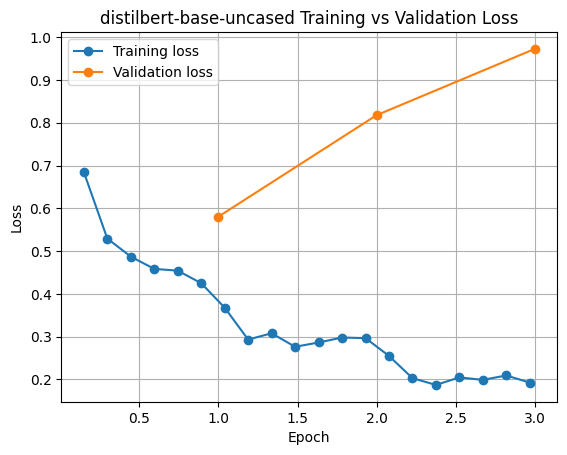

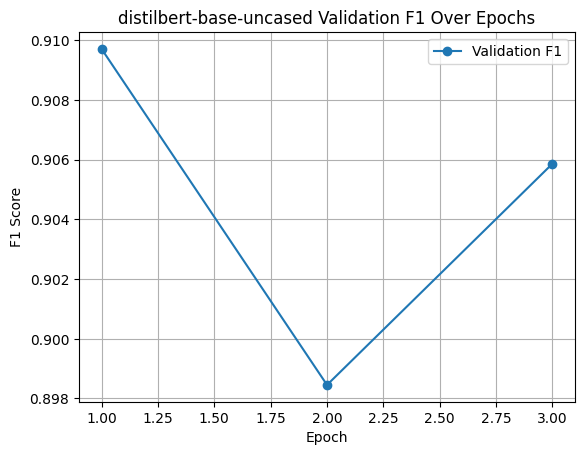

In [93]:
training_graphs(pd.DataFrame(trainer_model_1.state.log_history), model_1)

## Model 2: bert-base-uncased

In [94]:
trainer_model_2 = train_model(
    model_name = model_2,
    tokenizer = tokenizer_model_2,
    tokenized_train_dataset = tokenized_sst2_model_2["train"],
    tokenized_validation_dataset = tokenized_sst2_model_2["validation"],
    output_dir = "./model_2_sst2_baseline",
    compute_metrics = compute_metrics,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.402929,0.462578,0.914798,0.918919,0.916854,0.915138
2,0.295843,0.608329,0.918860,0.943694,0.931111,0.928899
3,0.179837,0.763413,0.912664,0.941441,0.926829,0.924312


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

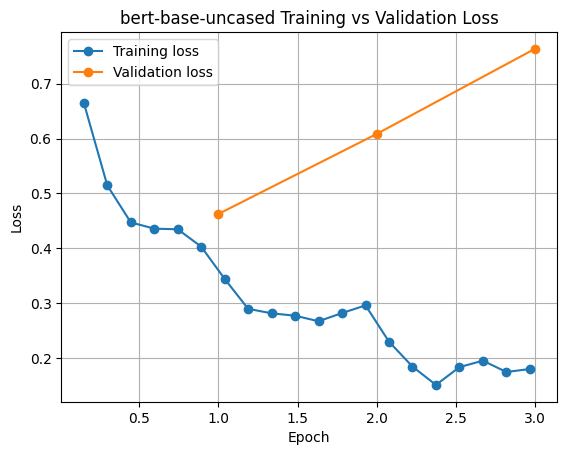

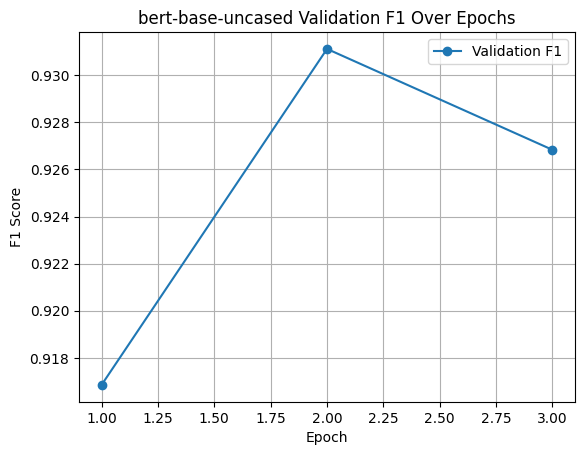

In [95]:
training_graphs(pd.DataFrame(trainer_model_2.state.log_history), model_2)

## Model 3: roberta-base

In [96]:
trainer_model_3 = train_model(
    model_name = model_3,
    tokenizer = tokenizer_model_3,
    tokenized_train_dataset = tokenized_sst2_model_3["train"],
    tokenized_validation_dataset = tokenized_sst2_model_3["validation"],
    output_dir = "./model_3_sst2_baseline",
    compute_metrics = compute_metrics,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along d

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.482561,0.432262,0.937220,0.941441,0.939326,0.938073
2,0.407542,0.614238,0.919565,0.952703,0.935841,0.933486
3,0.256533,0.667089,0.935412,0.945946,0.940649,0.939220


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

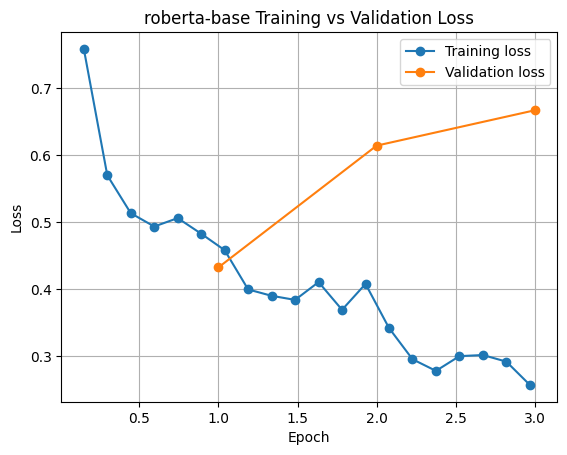

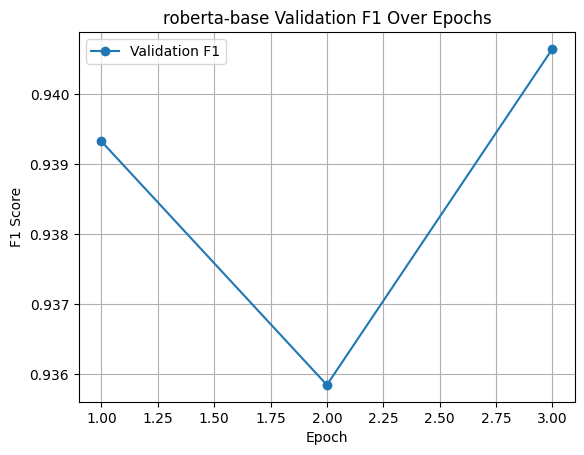

In [97]:
training_graphs(pd.DataFrame(trainer_model_3.state.log_history), model_3)

# Evaluating the 3 Models

This section runs an evaluation of each model on the clean tokenized dataset without any noise.

## Model 1: distilbert_base_uncased

In [98]:
model_1_results = model_evaluation(tokenized_sst2_model_1["test"], trainer_model_1, "Clean")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


 Data  Loss  Accuracy  Precision  Recall   F1
Clean 0.341     0.945      0.962   0.939 0.95


## Model 2: bert-base-uncased

In [99]:
model_2_results = model_evaluation(tokenized_sst2_model_2["test"], trainer_model_2, "Clean")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


 Data  Loss  Accuracy  Precision  Recall    F1
Clean 0.387     0.956      0.963   0.958 0.961


## Model 3: roberta-base

In [100]:
model_3_results = model_evaluation(tokenized_sst2_model_3["test"], trainer_model_3, "Clean")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


 Data  Loss  Accuracy  Precision  Recall    F1
Clean 0.517     0.951      0.958   0.954 0.956


# Evaluating the 3 Models on Noisy Data

This section proceeds to add different levels of noise to each dataset and then evaluate each model on those different noisy datasets. 

## OCR Noise

   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.1 1.141     0.799      0.955    0.67 0.788


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.2 2.677     0.559      0.915   0.231 0.368


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.3 3.345     0.453      0.722   0.031 0.059


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.4 3.237     0.449       0.68   0.022 0.043


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.5 3.258     0.444        0.6   0.008 0.017
      Data   Loss  Accuracy  Precision  Recall     F1
0  OCR 0.1  1.141     0.799      0.955   0.670  0.788
0  OCR 0.2  2.677     0.559      0.915   0.231  0.368
0  OCR 0.3  3.345     0.453      0.722   0.031  0.059
0  OCR 0.4  3.237     0.449      0.680   0.022  0.043
0  OCR 0.5  3.258     0.444      0.600   0.008  0.017


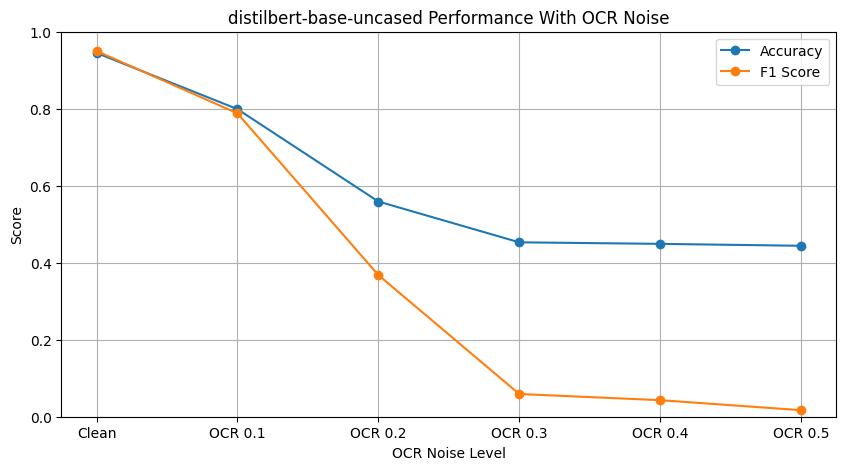

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.1 1.037      0.87      0.933   0.827 0.877


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.2 2.962     0.627      0.873   0.387 0.536


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.3 4.506     0.459      0.689   0.056 0.104


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.4 4.578     0.453      0.665   0.039 0.073


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall   F1
OCR 0.5  4.68     0.445       0.61   0.015 0.03
      Data   Loss  Accuracy  Precision  Recall     F1
0  OCR 0.1  1.037     0.870      0.933   0.827  0.877
0  OCR 0.2  2.962     0.627      0.873   0.387  0.536
0  OCR 0.3  4.506     0.459      0.689   0.056  0.104
0  OCR 0.4  4.578     0.453      0.665   0.039  0.073
0  OCR 0.5  4.680     0.445      0.610   0.015  0.030


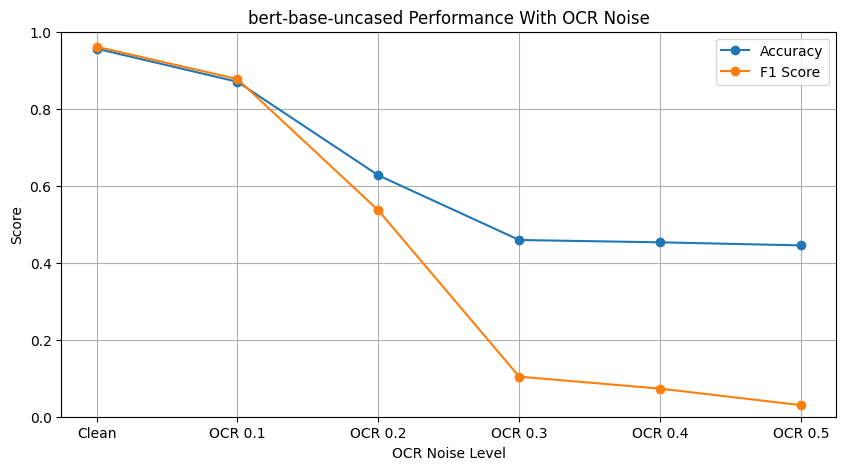

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.1 1.204     0.882      0.921   0.862 0.891


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.2 2.584     0.724      0.787   0.692 0.736


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.3 3.181     0.581      0.634   0.589 0.611


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.4 3.115     0.563      0.615   0.582 0.598


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   Data  Loss  Accuracy  Precision  Recall    F1
OCR 0.5 3.043     0.533      0.593   0.521 0.555
      Data   Loss  Accuracy  Precision  Recall     F1
0  OCR 0.1  1.204     0.882      0.921   0.862  0.891
0  OCR 0.2  2.584     0.724      0.787   0.692  0.736
0  OCR 0.3  3.181     0.581      0.634   0.589  0.611
0  OCR 0.4  3.115     0.563      0.615   0.582  0.598
0  OCR 0.5  3.043     0.533      0.593   0.521  0.555


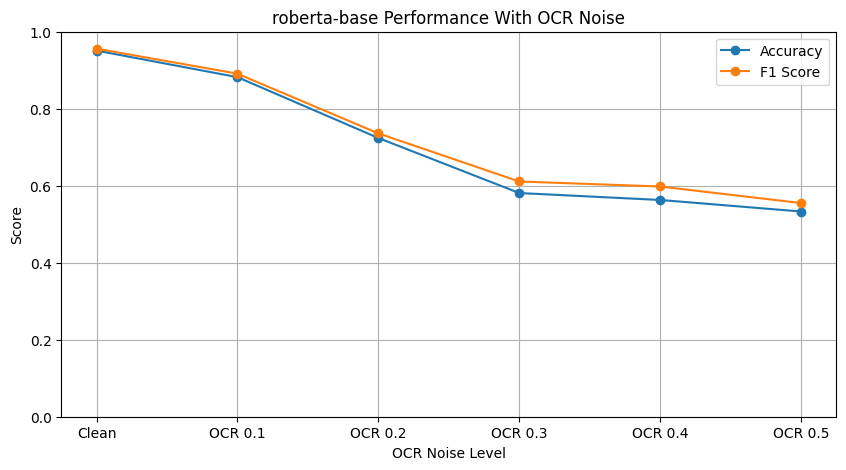

In [105]:
ocr_results_df = all_models_for_noise(
    [tokenizer_model_1, tokenizer_model_2, tokenizer_model_3],
    [trainer_model_1, trainer_model_2, trainer_model_3],
    [model_1_results, model_2_results, model_3_results],
    [model_1, model_2, model_3],
    add_ocr_noise,
    "OCR",
    [0.1, 0.2, 0.3, 0.4, 0.5]
)

## Typo Noise

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.1 1.272     0.778      0.948   0.637 0.762


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.2  2.46     0.583      0.909    0.28 0.428


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.3 3.108     0.468       0.77   0.066 0.122


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.4 3.051     0.461      0.736   0.052 0.096


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall   F1
Typo 0.5 3.055      0.45      0.625   0.037 0.07
       Data   Loss  Accuracy  Precision  Recall     F1
0  Typo 0.1  1.272     0.778      0.948   0.637  0.762
0  Typo 0.2  2.460     0.583      0.909   0.280  0.428
0  Typo 0.3  3.108     0.468      0.770   0.066  0.122
0  Typo 0.4  3.051     0.461      0.736   0.052  0.096
0  Typo 0.5  3.055     0.450      0.625   0.037  0.070


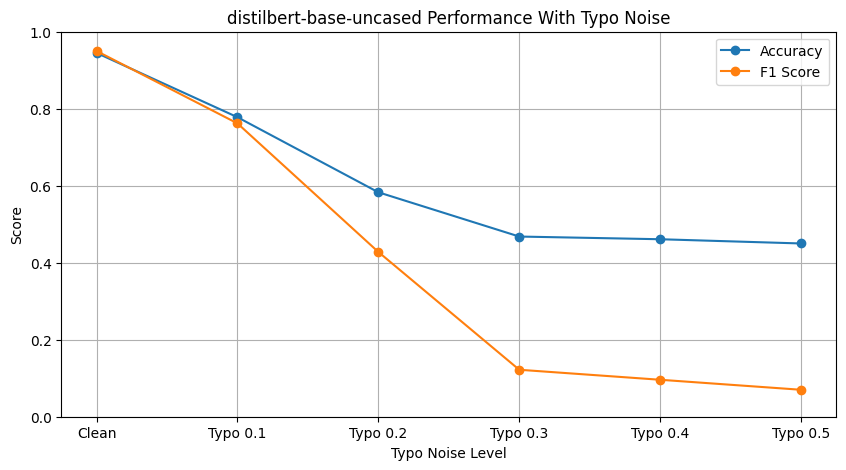

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall   F1
Typo 0.1 1.173     0.854      0.923   0.805 0.86


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.2 2.525     0.659      0.854   0.469 0.606


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.4 3.626     0.476       0.68   0.115 0.197


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.5 3.715     0.459      0.627   0.074 0.133
       Data   Loss  Accuracy  Precision  Recall     F1
0  Typo 0.1  1.173     0.854      0.923   0.805  0.860
0  Typo 0.2  2.525     0.659      0.854   0.469  0.606
0  Typo 0.3  3.603     0.492      0.714   0.150  0.248
0  Typo 0.4  3.626     0.476      0.680   0.115  0.197
0  Typo 0.5  3.715     0.459      0.627   0.074  0.133


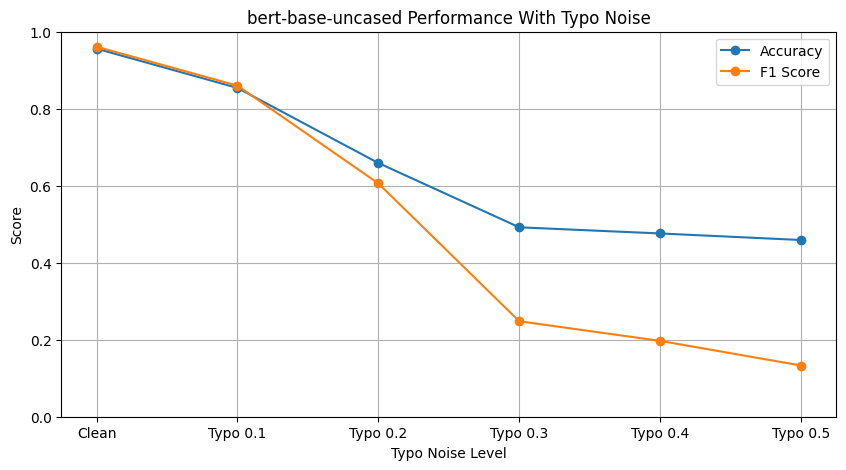

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.1 1.374     0.866      0.904   0.849 0.876


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.2 2.453     0.739        0.8   0.709 0.752


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.4 3.228     0.581      0.643   0.558 0.597


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


    Data  Loss  Accuracy  Precision  Recall    F1
Typo 0.5 3.245     0.529       0.59   0.512 0.548
       Data   Loss  Accuracy  Precision  Recall     F1
0  Typo 0.1  1.374     0.866      0.904   0.849  0.876
0  Typo 0.2  2.453     0.739      0.800   0.709  0.752
0  Typo 0.3  3.234     0.599      0.667   0.564  0.611
0  Typo 0.4  3.228     0.581      0.643   0.558  0.597
0  Typo 0.5  3.245     0.529      0.590   0.512  0.548


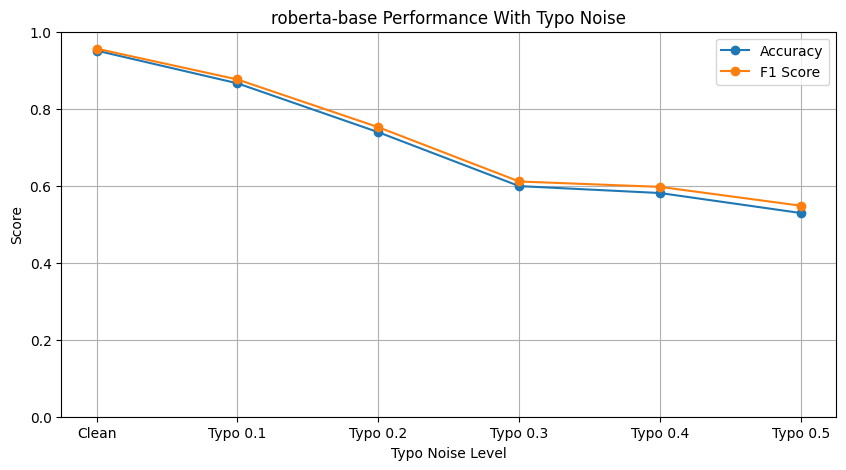

In [106]:
typo_results_df = all_models_for_noise(
    [tokenizer_model_1, tokenizer_model_2, tokenizer_model_3],
    [trainer_model_1, trainer_model_2, trainer_model_3],
    [model_1_results, model_2_results, model_3_results],
    [model_1, model_2, model_3],
    add_typo_noise,
    "Typo",
    [0.1, 0.2, 0.3, 0.4, 0.5]
)

## Spacing Noise

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.1 1.347     0.764      0.952   0.608 0.742


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.2 2.275       0.6      0.919   0.309 0.463


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

...

       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.4 2.765     0.485      0.818   0.098 0.176


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.5 2.791     0.454       0.67   0.042 0.079
          Data   Loss  Accuracy  Precision  Recall     F1
0  Spacing 0.1  1.347     0.764      0.952   0.608  0.742
0  Spacing 0.2  2.275     0.600      0.919   0.309  0.463
0  Spacing 0.3  2.809     0.491      0.832   0.109  0.193
0  Spacing 0.4  2.765     0.485      0.818   0.098  0.176
0  Spacing 0.5  2.791     0.454      0.670   0.042  0.079


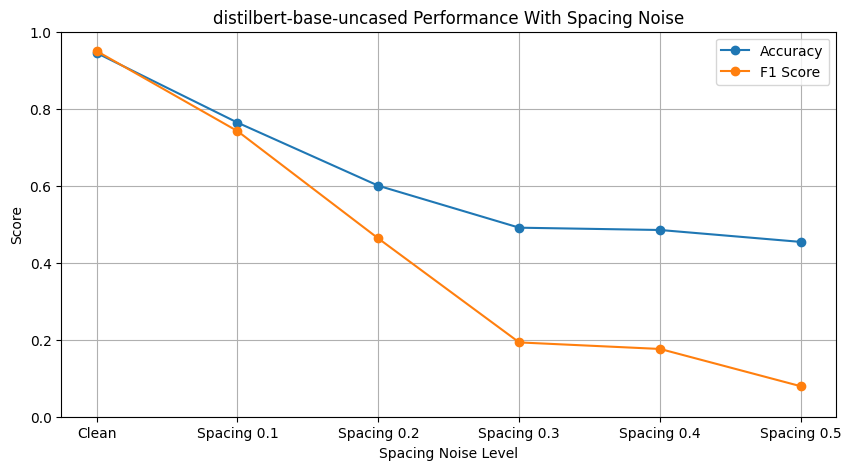

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.1 1.152     0.849      0.919   0.801 0.856


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.2 2.078     0.685       0.86    0.52 0.648


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.4 2.752     0.516      0.766   0.191 0.306


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.5 2.846     0.468      0.639   0.105 0.181
          Data   Loss  Accuracy  Precision  Recall     F1
0  Spacing 0.1  1.152     0.849      0.919   0.801  0.856
0  Spacing 0.2  2.078     0.685      0.860   0.520  0.648
0  Spacing 0.3  2.767     0.532      0.756   0.236  0.360
0  Spacing 0.4  2.752     0.516      0.766   0.191  0.306
0  Spacing 0.5  2.846     0.468      0.639   0.105  0.181


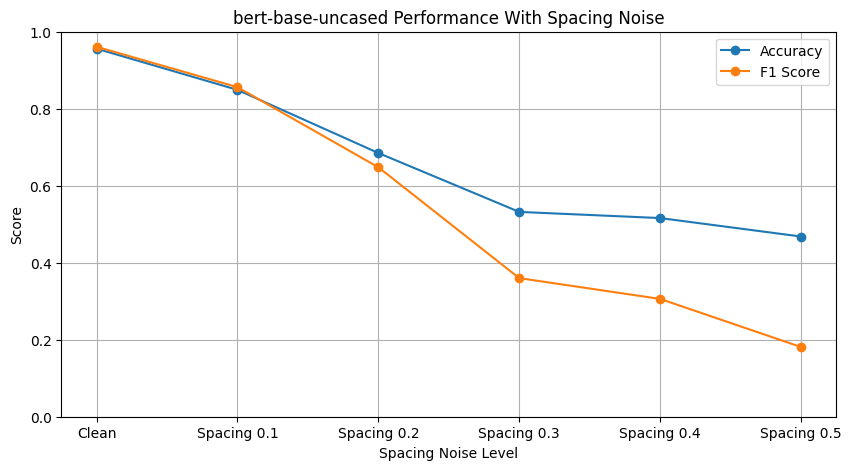

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.1 1.323     0.871      0.907   0.857 0.881


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.2 2.491     0.744      0.811   0.704 0.754


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.4 3.621     0.588      0.701   0.456 0.553


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


       Data  Loss  Accuracy  Precision  Recall    F1
Spacing 0.5 4.209     0.513      0.626   0.317 0.421
          Data   Loss  Accuracy  Precision  Recall     F1
0  Spacing 0.1  1.323     0.871      0.907   0.857  0.881
0  Spacing 0.2  2.491     0.744      0.811   0.704  0.754
0  Spacing 0.3  3.448     0.614      0.701   0.538  0.609
0  Spacing 0.4  3.621     0.588      0.701   0.456  0.553
0  Spacing 0.5  4.209     0.513      0.626   0.317  0.421


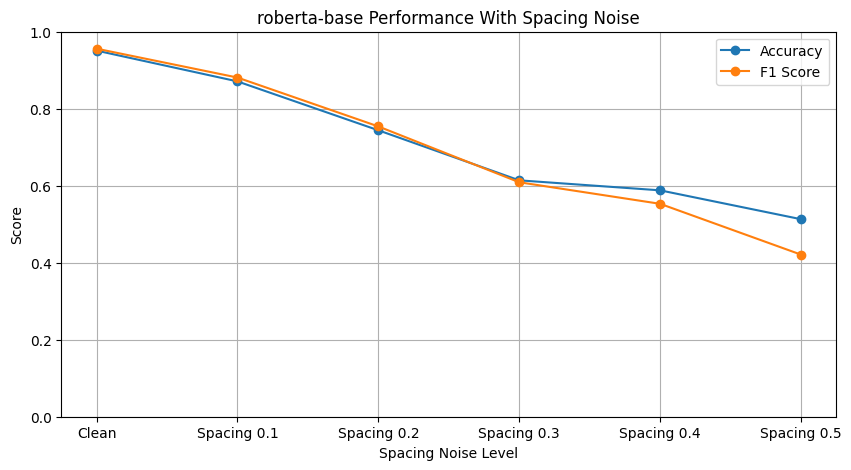

In [107]:
spacing_results_df = all_models_for_noise(
    [tokenizer_model_1, tokenizer_model_2, tokenizer_model_3],
    [trainer_model_1, trainer_model_2, trainer_model_3],
    [model_1_results, model_2_results, model_3_results],
    [model_1, model_2, model_3],
    add_space_noise,
    "Spacing",
    [0.1, 0.2, 0.3, 0.4, 0.5]
)

# Exporting Results

In [108]:
all_results_df = pd.concat(
    [
        ocr_results_df,
        typo_results_df,
        spacing_results_df
    ],
    ignore_index=True
)

all_results_df.to_excel("sentiment_noise_results.xlsx", index=False)

In [109]:
print(all_results_df)

                      Model Noise Type         Data   Loss  Accuracy  \
0   distilbert-base-uncased        OCR        Clean  0.341     0.945   
1   distilbert-base-uncased        OCR      OCR 0.1  1.141     0.799   
2   distilbert-base-uncased        OCR      OCR 0.2  2.677     0.559   
3   distilbert-base-uncased        OCR      OCR 0.3  3.345     0.453   
4   distilbert-base-uncased        OCR      OCR 0.4  3.237     0.449   
5   distilbert-base-uncased        OCR      OCR 0.5  3.258     0.444   
6         bert-base-uncased        OCR        Clean  0.387     0.956   
7         bert-base-uncased        OCR      OCR 0.1  1.037     0.870   
8         bert-base-uncased        OCR      OCR 0.2  2.962     0.627   
9         bert-base-uncased        OCR      OCR 0.3  4.506     0.459   
10        bert-base-uncased        OCR      OCR 0.4  4.578     0.453   
11        bert-base-uncased        OCR      OCR 0.5  4.680     0.445   
12             roberta-base        OCR        Clean  0.517     0